### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [12]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [2]:
df.sort_values(by='total_litres_of_pure_alcohol', ascending=False).head(10)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
15,Belarus,142,373,42,14.4
98,Lithuania,343,244,56,12.9
3,Andorra,245,138,312,12.4
68,Grenada,199,438,28,11.9
61,France,127,151,370,11.8
45,Czech Republic,361,170,134,11.8
141,Russian Federation,247,326,73,11.5
99,Luxembourg,236,133,271,11.4
155,Slovakia,196,293,116,11.4
81,Ireland,313,118,165,11.4


In [3]:

media_birra = df['beer_servings'].mean()
media_vino = df['wine_servings'].mean()
media_distillati = df['spirit_servings'].mean()
print(media_birra, media_vino, media_distillati)

#import numpy as np
#np.mean(df['beer_servings'].values)   

106.16062176165804 49.45077720207254 80.99481865284974


In [4]:
# Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`
nuova_colonna = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings'])/3
# oppure con l'utilizzo di mean
df[['beer_servings', 'wine_servings', 'spirit_servings']].mean(axis=1)


df['alcohol_index'] = nuova_colonna
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
0,Afghanistan,0,0,0,0.0,0.000000
1,Albania,89,132,54,4.9,91.666667
2,Algeria,25,0,14,0.7,13.000000
3,Andorra,245,138,312,12.4,231.666667
4,Angola,217,57,45,5.9,106.333333
...,...,...,...,...,...,...
188,Venezuela,333,100,3,7.7,145.333333
189,Vietnam,111,2,1,2.0,38.000000
190,Yemen,6,0,0,0.1,2.000000
191,Zambia,32,19,4,2.5,18.333333


In [5]:
# Trova il paese con il valore massimo di alcohol_index
df.sort_values(by='alcohol_index', ascending=False).head(1)

# oppure con max
df[df['alcohol_index'] == df['alcohol_index'].max()]

# oppure con argmax
df['alcohol_index'].argmax()

np.int64(3)

In [6]:
# Filtra solo i paesi che consumano più di 100 birre all’anno
df[df['beer_servings'] > 100]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
3,Andorra,245,138,312,12.4,231.666667
4,Angola,217,57,45,5.9,106.333333
5,Antigua & Barbuda,102,128,45,4.9,91.666667
6,Argentina,193,25,221,8.3,146.333333
8,Australia,261,72,212,10.4,181.666667
...,...,...,...,...,...,...
182,United Kingdom,219,126,195,10.4,180.000000
184,USA,249,158,84,8.7,163.666667
185,Uruguay,115,35,220,6.6,123.333333
188,Venezuela,333,100,3,7.7,145.333333


<Axes: xlabel='country'>

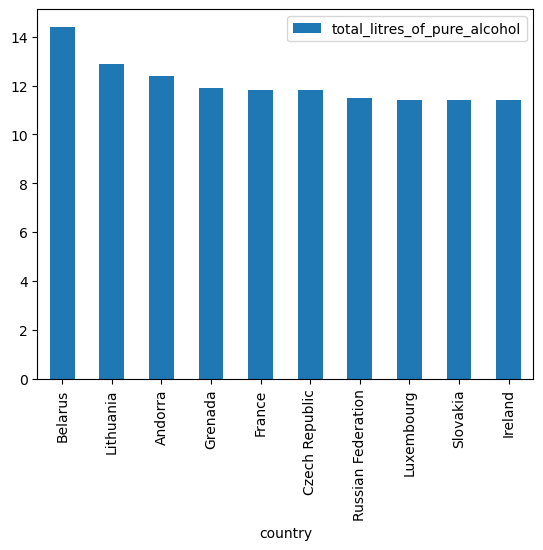

In [20]:
# Bar chart
# Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

df_max_10 = df.sort_values(by='total_litres_of_pure_alcohol', ascending=False).head(10)
df_max_10.plot(x="country", y="total_litres_of_pure_alcohol", kind="bar")

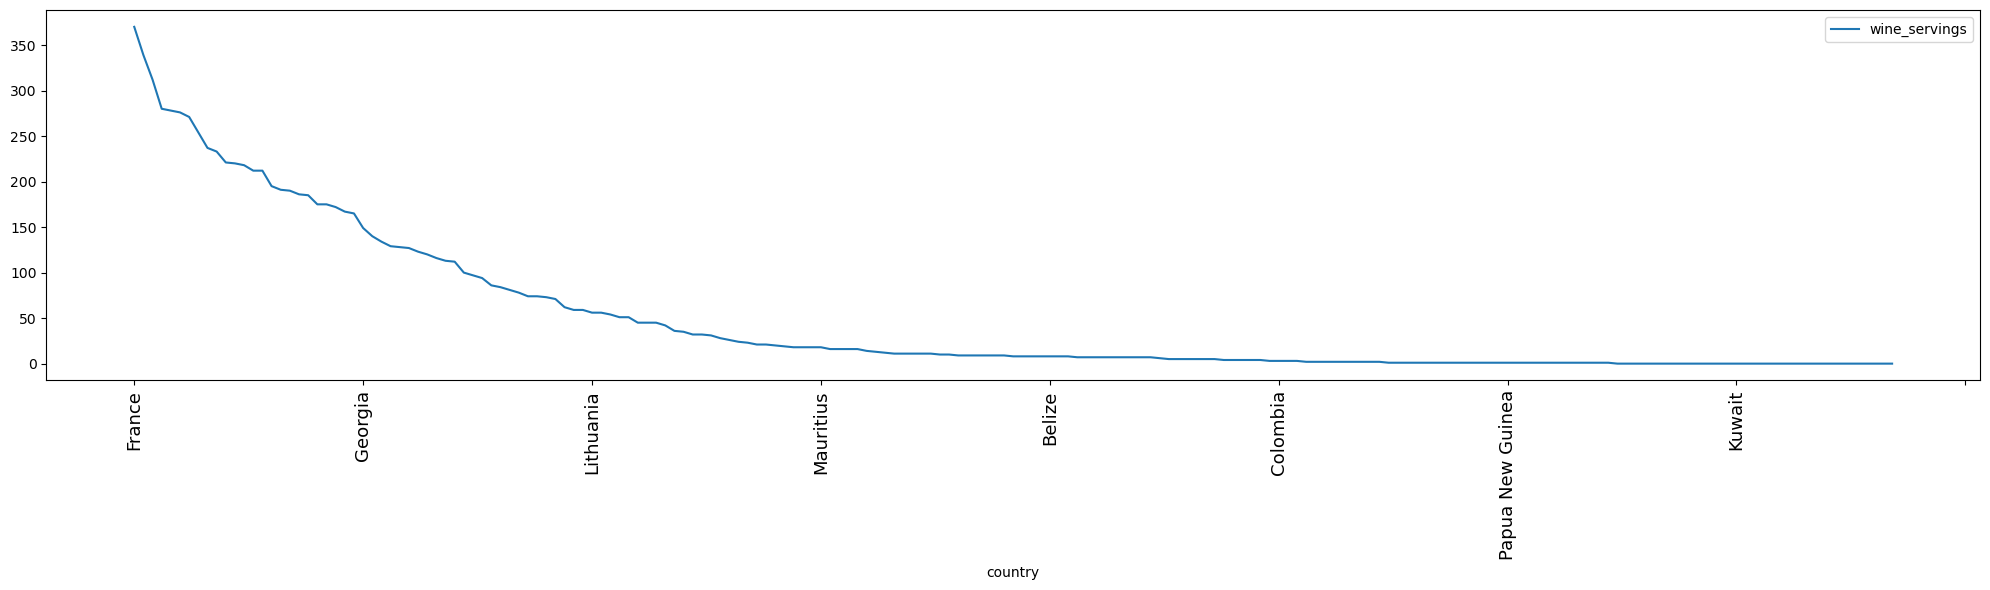

In [38]:
# Crea un line plot con wine_servings ordinato per paese (usa sort_values)
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by="wine_servings", ascending=False)
df_sorted.plot(x="country", y="wine_servings", kind="line", figsize=(20, 6))

plt.xticks(rotation=90, fontsize=13)
plt.tight_layout()  # evita che le etichette vengano tagliate
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [7]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [8]:
year_salary = df.groupby('job_country')['salary_year_avg'].mean()
job_count = df.groupby('job_country').count()
min = df.groupby('job_country')['salary_year_avg'].min()
max = df.groupby('job_country')['salary_year_avg'].max()
print(f'{year_salary}, {job_count}, {min}, {max}')

job_country
Afghanistan              NaN
Albania         79472.500000
Algeria         44550.000000
Angola                   NaN
Argentina      105212.343750
                   ...      
Venezuela                NaN
Vietnam         90927.236364
Yemen                    NaN
Zambia          90670.000000
Zimbabwe        67056.666667
Name: salary_year_avg, Length: 160, dtype: float64,              job_title_short  job_title  job_location  job_via  \
job_country                                                      
Afghanistan               16         16            16       16   
Albania                  119        119           119      119   
Algeria                  111        111           111      111   
Angola                    11         11            11       11   
Argentina               8736       8736          8736     8736   
...                      ...        ...           ...      ...   
Venezuela                 69         69            69       69   
Vietnam                

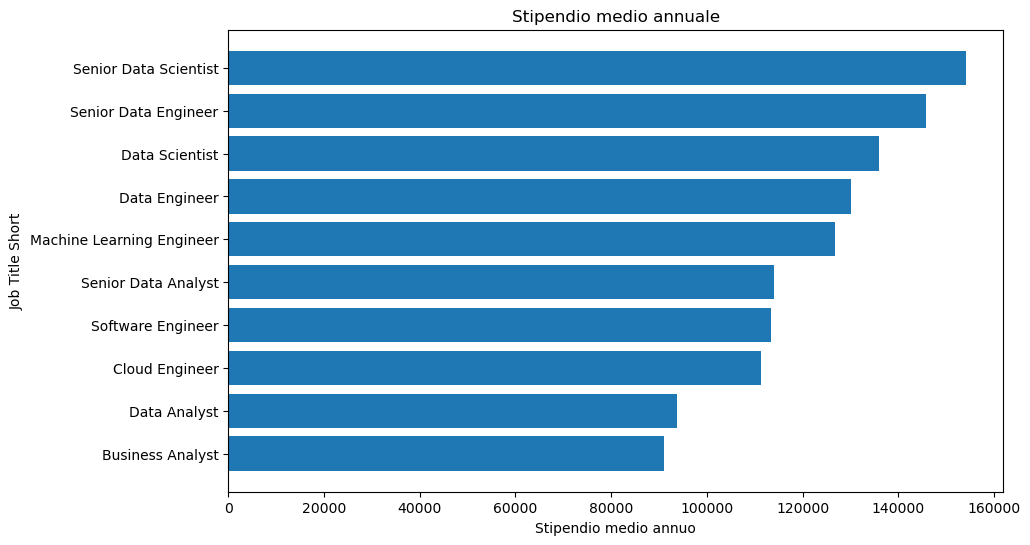

In [9]:
import matplotlib.pyplot as plt
stipendio_medio_per_job_title = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending = True)
plt.figure(figsize=(10,6))
plt.xlabel("Stipendio medio annuo")
plt.ylabel("Job Title Short")
plt.title("Stipendio medio annuale")
plt.barh(stipendio_medio_per_job_title.index, stipendio_medio_per_job_title.values)
#plt.gca().invert_yaxis()
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [39]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


=== Analisi vendite per giorno ===
      conto_medio  conteggio  minimo  massimo
day                                          
Fri         17.15         19    5.75    40.17
Sat         20.44         87    3.07    50.81
Sun         21.41         76    7.25    48.17
Thur        17.68         62    7.51    43.11

=== Prime righe con conto_per_persona ===
   day  total_bill  size  conto_per_persona
0  Sun       16.99     2               8.49
1  Sun       10.34     3               3.45
2  Sun       21.01     3               7.00
3  Sun       23.68     2              11.84
4  Sun       24.59     4               6.15

=== Giorno con conto medio più alto ===
Sun: $21.41


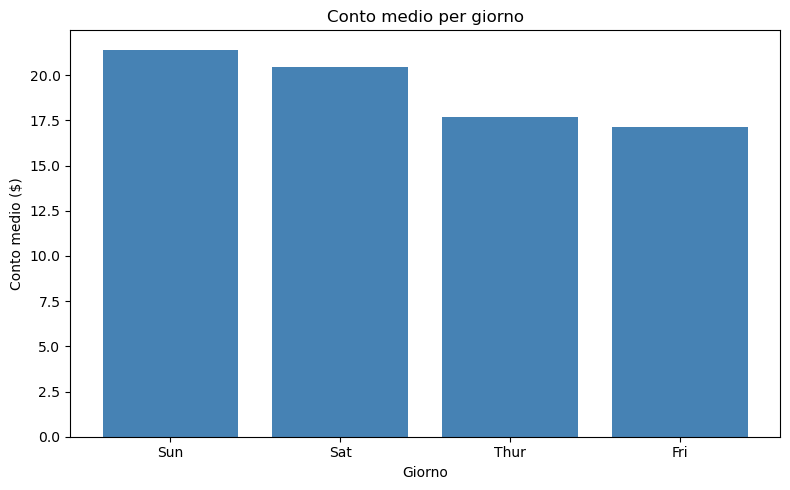

In [40]:
import pandas as pd
import matplotlib.pyplot as plt


# Analisi esplorativa per giorno
analisi = df.groupby('day')['total_bill'].agg(
    conto_medio='mean',
    conteggio='count',
    minimo='min',
    massimo='max'
).round(2)

print("=== Analisi vendite per giorno ===")
print(analisi)

# Nuova colonna conto_per_persona
df['conto_per_persona'] = (df['total_bill'] / df['size']).round(2)
print("\n=== Prime righe con conto_per_persona ===")
print(df[['day', 'total_bill', 'size', 'conto_per_persona']].head())

# Giorno con conto medio più alto
giorno_top = analisi['conto_medio'].idxmax()
valore_top = analisi['conto_medio'].max()
print(f"\n=== Giorno con conto medio più alto ===")
print(f"{giorno_top}: ${valore_top}")

# Grafico a barre ordinato
df_sorted = analisi['conto_medio'].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_sorted.index, df_sorted.values, color='steelblue')
plt.title('Conto medio per giorno')
plt.xlabel('Giorno')
plt.ylabel('Conto medio ($)')
plt.tight_layout()
plt.show()